In [1]:
import pandas as pd
from pathlib import Path
import utils.helpers as utils_helpers

## 1. Reproduction of Figure 3

In [2]:
df_test_pairs = pd.read_pickle(Path("..") / "data" / "datasets" / "df_test_pairs.pkl")
df_train_pairs = pd.read_pickle(Path("..") / "data" / "datasets" / "df_train_pairs.pkl")

df_test_unpaired = utils_helpers.unpack_pairs_df(df_test_pairs)
df_train_unpaired = utils_helpers.unpack_pairs_df(df_train_pairs)

group_sizes = df_train_unpaired.groupby('Identifier').size().rename('training_group_size')
df_test_pairs = df_test_pairs.drop(columns=['training_group_size'], errors='ignore').join(group_sizes, on='Identifier')
df_test_pairs['training_group_size'] = df_test_pairs['training_group_size'].fillna(0).astype(int)
df_test_pairs

,Identifier,Type,index,log10kcat,training_group_size
0,0,"[mutant, wildtype]","[1, 3]","[1.8617646881713763, 1.8993552436810253]",3
1,15,"[wildtype, mutant]","[14, 12]","[3.798650645445269, 2.7481880270062002]",9
2,32,"[mutant, wildtype]","[26, 28]","[-1.1481308288220342, 0.5046067706419538]",6
3,34,"[wildtype, mutant]","[40, 42]","[0.7234548960673006, 1.4563660331290431]",7
4,38,"[wildtype, mutant]","[50, 46]","[1.4356268182208625, -1.074922771381542]",8
...,...,...,...,...,...
1603,6950,"[wildtype, mutant]","[8257, 8266]","[1.4913616938342726, 0.9590413923210935]",8
1604,6950,"[mutant, wildtype]","[8259, 8257]","[1.2304489213782739, 1.4913616938342726]",8
1605,6950,"[mutant, mutant]","[8259, 8266]","[1.2304489213782739, 0.9590413923210935]",8
1606,6961,"[wildtype, mutant]","[8274, 8277]","[-1.525869054590876, -2.693084873947305]",10


In [3]:
df_train_pairs = pd.read_pickle(Path("..") / "data" / "datasets" / "df_train_pairs.pkl")
df_train_pairs['log10kcat'].explode().min()

-7.477121298149113

### Loading FCKcat

In [4]:
import xgboost as xgb
import json
import numpy as np

In [5]:
model_conc_absmax = xgb.Booster()
model_conc_absmax.load_model(Path("..") / "data" / "models" / "FCKcat.json")

In [6]:
# loading mapping dictionaries:
with open(Path("..") / "data" / "mapping" / "dict_index_to_sequence.json", 'r') as f:
    index_to_sequence = json.load(f)

with open(Path("..") / "data" / "mapping" / "dict_index_to_esm2_absmaxpooling.json", 'r') as f:
    index_to_esm2_absmaxpooling = json.load(f)

In [7]:
df_test_pairs = utils_helpers.add_esm2_absmax(df_test_pairs, index_to_esm2_absmaxpooling)
df_test_pairs = utils_helpers.prepro_v2(df_test_pairs)

## 1.1 Prediction of $\Delta k_{cat}$ on all test pairs (wt-mut, mut-wt and mut-mut)

In [8]:
from sklearn.metrics import r2_score

test_X = np.array(list(df_test_pairs["sequences_representation"]))
test_Y = np.array(list(df_test_pairs["delta_log_kcat"]))

dtest = xgb.DMatrix(test_X)  
predictions = model_conc_absmax.predict(dtest)

r2= r2_score(test_Y, predictions)

print(f"R2 Score validation : {r2}")

R2 Score validation : 0.44460947709396237


In [9]:
df_test_pairs['delta_log_kcat_predicted'] = predictions
df_test_pairs_mm = df_test_pairs[df_test_pairs['Type'].apply(lambda x: x == ["mutant", "mutant"])]
df_test_pairs_wm = df_test_pairs[df_test_pairs['Type'].apply(lambda x: x != ["mutant", "mutant"])]


Bad key text.latex.preview in file utils/CCB_plot_style_0v4.mplstyle, line 55 ('text.latex.preview  : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file utils/CCB_plot_style_0v4.mplstyle, line 63 ('mathtext.fallback_to_cm : True ## When True, use symbols from the Computer Modern fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


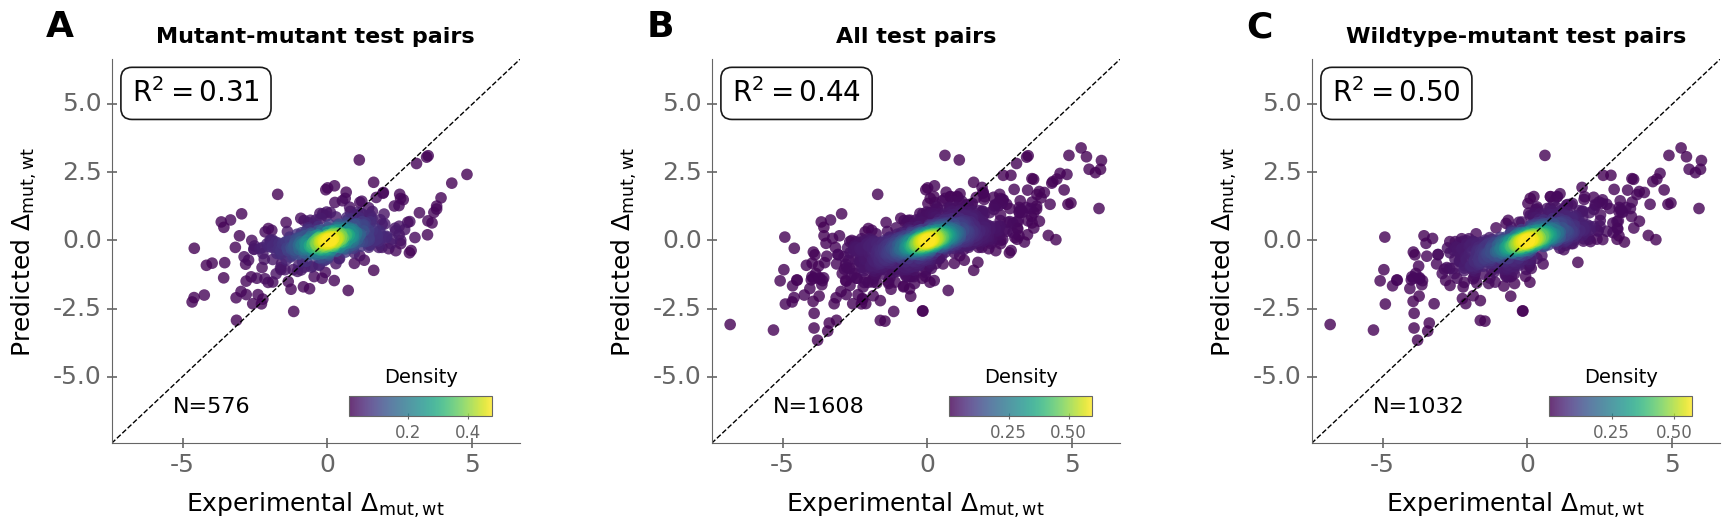

In [10]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

plt.style.use(Path("utils") / "CCB_plot_style_0v4.mplstyle")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

_xlab = r"Experimental $\Delta_{\mathrm{mut,wt}}$"
_ylab = r"Predicted $\Delta_{\mathrm{mut,wt}}$"

p1 = utils_helpers._scatter_panel_v2(axes[0], df_test_pairs_mm['delta_log_kcat'], df_test_pairs_mm['delta_log_kcat_predicted'], title=r"Mutant-mutant test pairs", x_label=_xlab, y_label=_ylab)
axes[0].text(0.15, 0.07, f"N={len(df_test_pairs_mm)}", transform=axes[0].transAxes, ha='left', va='bottom', fontsize=16)

p2 = utils_helpers._scatter_panel_v2(axes[1], df_test_pairs['delta_log_kcat'], df_test_pairs['delta_log_kcat_predicted'], title=r"All test pairs", x_label=_xlab, y_label=_ylab)
axes[1].text(0.15, 0.07, f"N={len(df_test_pairs)}", transform=axes[1].transAxes, ha='left', va='bottom', fontsize=16)

p3 = utils_helpers._scatter_panel_v2(axes[2], df_test_pairs_wm['delta_log_kcat'], df_test_pairs_wm['delta_log_kcat_predicted'], title=r"Wildtype-mutant test pairs", x_label=_xlab, y_label=_ylab)
axes[2].text(0.15, 0.07, f"N={len(df_test_pairs_wm)}", transform=axes[2].transAxes, ha='left', va='bottom', fontsize=16)

lims = utils_helpers._shared_row_limits([p1, p2, p3])
if lims is not None:
    lo, hi = lims
    for ax in axes:
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        for ln in list(ax.get_lines()):
            if ln.get_linestyle() == "--":
                ln.remove()
        ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.0)

for i, ax in enumerate(axes):
    ax.text(-0.16, 1.04, chr(65+i), transform=ax.transAxes, ha="left", va="bottom", fontsize=26, fontweight="bold", clip_on=False)

for ax in axes:
    ax.tick_params(axis="both", which="major", labelsize=18, length=7, width=1.2)
    ax.tick_params(axis="both", which="minor", labelsize=16, length=4, width=1.0)

fig.set_constrained_layout_pads(w_pad=0.45, h_pad=0.45, wspace=0.02, hspace=0.0)
plt.show()


Bad key text.latex.preview in file utils/CCB_plot_style_0v4.mplstyle, line 55 ('text.latex.preview  : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file utils/CCB_plot_style_0v4.mplstyle, line 63 ('mathtext.fallback_to_cm : True ## When True, use symbols from the Computer Modern fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


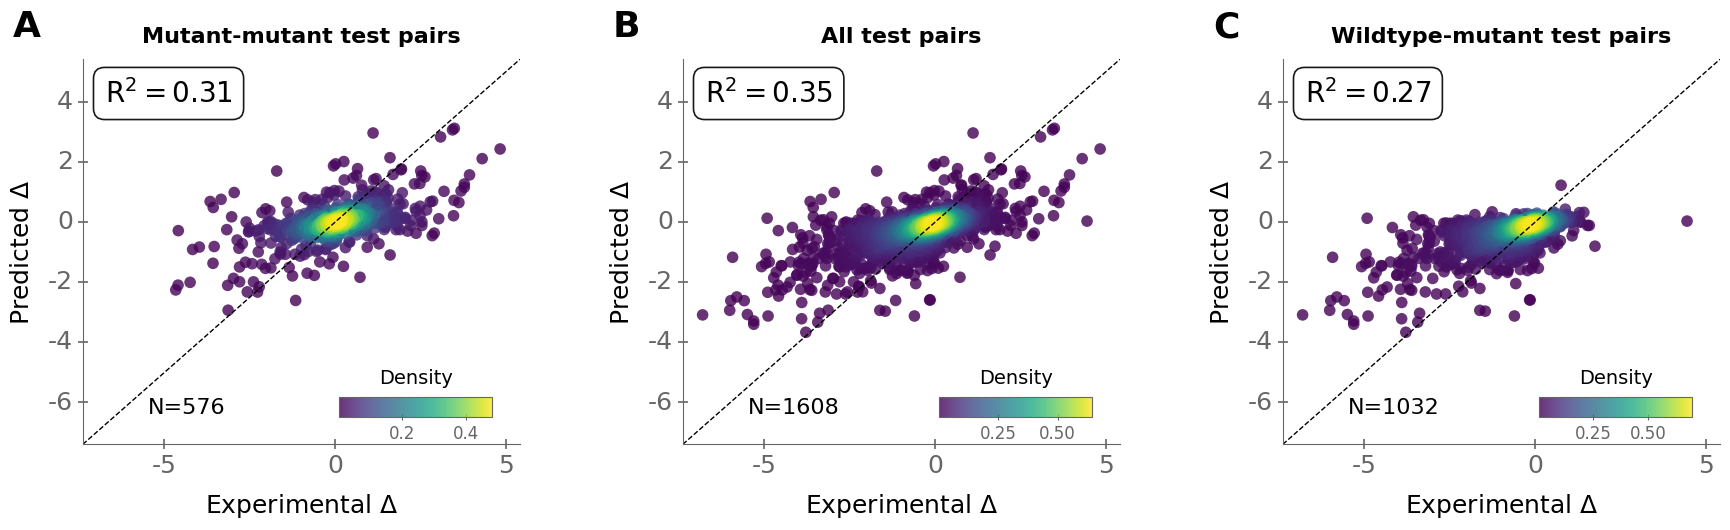

In [11]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

plt.style.use(Path("utils") / "CCB_plot_style_0v4.mplstyle")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

_xlab = r"Experimental $\Delta$"
_ylab = r"Predicted $\Delta$"

_wt_mut_all = df_test_pairs['Type'].apply(lambda x: x == ['wildtype', 'mutant'])
_x_all = df_test_pairs['delta_log_kcat'].where(~_wt_mut_all, -df_test_pairs['delta_log_kcat'])
_y_all = df_test_pairs['delta_log_kcat_predicted'].where(~_wt_mut_all, -df_test_pairs['delta_log_kcat_predicted'])

_wt_mut_wm = df_test_pairs_wm['Type'].apply(lambda x: x == ['wildtype', 'mutant'])
_x_wm = df_test_pairs_wm['delta_log_kcat'].where(~_wt_mut_wm, -df_test_pairs_wm['delta_log_kcat'])
_y_wm = df_test_pairs_wm['delta_log_kcat_predicted'].where(~_wt_mut_wm, -df_test_pairs_wm['delta_log_kcat_predicted'])

p1 = utils_helpers._scatter_panel_v2(axes[0], df_test_pairs_mm['delta_log_kcat'], df_test_pairs_mm['delta_log_kcat_predicted'], title=r"Mutant-mutant test pairs", x_label=_xlab, y_label=_ylab)
axes[0].text(0.15, 0.07, f"N={len(df_test_pairs_mm)}", transform=axes[0].transAxes, ha='left', va='bottom', fontsize=16)

p2 = utils_helpers._scatter_panel_v2(axes[1], _x_all, _y_all, title=r"All test pairs", x_label=_xlab, y_label=_ylab)
axes[1].text(0.15, 0.07, f"N={len(df_test_pairs)}", transform=axes[1].transAxes, ha='left', va='bottom', fontsize=16)

p3 = utils_helpers._scatter_panel_v2(axes[2], _x_wm, _y_wm, title=r"Wildtype-mutant test pairs", x_label=_xlab, y_label=_ylab)
axes[2].text(0.15, 0.07, f"N={len(df_test_pairs_wm)}", transform=axes[2].transAxes, ha='left', va='bottom', fontsize=16)

lims = utils_helpers._shared_row_limits([p1, p2, p3])
if lims is not None:
    lo, hi = lims
    for ax in axes:
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        for ln in list(ax.get_lines()):
            if ln.get_linestyle() == "--":
                ln.remove()
        ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.0)

for i, ax in enumerate(axes):
    ax.text(-0.16, 1.04, chr(65+i), transform=ax.transAxes, ha="left", va="bottom", fontsize=26, fontweight="bold", clip_on=False)

for ax in axes:
    ax.tick_params(axis="both", which="major", labelsize=18, length=7, width=1.2)
    ax.tick_params(axis="both", which="minor", labelsize=16, length=4, width=1.0)

fig.set_constrained_layout_pads(w_pad=0.45, h_pad=0.45, wspace=0.02, hspace=0.0)
plt.show()

## 2. Reproduction of Figure S6 (Predictions functions of group size)

In [12]:
df_test_pairs_wm_unseen = df_test_pairs_wm[df_test_pairs_wm['training_group_size'] == 0]

In [13]:

df_mutant_kcat = pd.DataFrame(columns=['Identifier', 'index', 'log10kcat'])
df_wildtype_kcat_test = pd.DataFrame(columns=['Identifier', 'index', 'log10kcat'])
for ind in df_test_pairs.index:
    type_list = df_test_pairs.loc[ind, 'Type']
    identifier = df_test_pairs.loc[ind, 'Identifier']
    ind1, ind2 = df_test_pairs.loc[ind, 'index']
    log10kcat1, log10kcat2 = df_test_pairs.loc[ind, 'log10kcat']

    if type_list == ["mutant", "mutant"]:
        df_mutant_kcat = pd.concat([
            df_mutant_kcat,
            pd.DataFrame({'Identifier': [identifier], 'index': [ind1], 'log10kcat': [log10kcat1]}),
            pd.DataFrame({'Identifier': [identifier], 'index': [ind2], 'log10kcat': [log10kcat2]}),
        ], ignore_index=True)

    elif type_list == ["wildtype", "mutant"]:
        df_mutant_kcat = pd.concat([
            df_mutant_kcat,
            pd.DataFrame({'Identifier': [identifier], 'index': [ind2], 'log10kcat': [log10kcat2]}),
        ], ignore_index=True)
        df_wildtype_kcat_test = pd.concat([
            df_wildtype_kcat_test,
            pd.DataFrame({'Identifier': [identifier], 'index': [ind1], 'log10kcat': [log10kcat1]}),
        ], ignore_index=True)

    elif type_list == ["mutant", "wildtype"]:
        df_mutant_kcat = pd.concat([
            df_mutant_kcat,
            pd.DataFrame({'Identifier': [identifier], 'index': [ind1], 'log10kcat': [log10kcat1]}),
        ], ignore_index=True)
        df_wildtype_kcat_test = pd.concat([
            df_wildtype_kcat_test,
            pd.DataFrame({'Identifier': [identifier], 'index': [ind2], 'log10kcat': [log10kcat2]}),
        ], ignore_index=True)
# remove duplicates
df_mutant_kcat = df_mutant_kcat.drop_duplicates().reset_index(drop=True)

In [15]:
df_mutant_kcat.to_pickle(Path("..") / "data" / "datasets" / "checkpoints" / "df_mutant_kcat_cp1.pkl")
df_train_unpaired.to_pickle(Path("..") / "data" / "datasets" / "checkpoints" / "df_train_unpaired_cp1.pkl")

#### checkpoint 1

In [14]:
import pandas as pd
df_mutant_kcat = pd.read_pickle(Path("..") / "data" / "datasets" / "checkpoints" / "df_mutant_kcat_cp1.pkl")
df_train_pairs = pd.read_pickle(Path("..") / "data" / "datasets" / "df_train_pairs.pkl")
df_train_unpaired = pd.read_pickle(Path("..") / "data" / "datasets" / "checkpoints" / "df_train_unpaired_cp1.pkl")

(The cell below takes approx 30sec)

In [15]:
df_mutant_kcat['predicted_log10kcat'] = np.nan
df_mutant_kcat['collective_pred'] = np.nan
for idx, row in df_mutant_kcat.iterrows():
    identifier = row['Identifier']
    index = row['index']
    df_temp = df_train_unpaired[df_train_unpaired['Identifier'] == identifier]

    if df_temp.empty:

        df_temp_wt = df_wildtype_kcat_test[df_wildtype_kcat_test['Identifier'] == identifier]
        kcat_wt = df_temp_wt['log10kcat'].values[0] if not df_temp_wt.empty else None
        index_wt = df_temp_wt['index'].values[0] if not df_temp_wt.empty else None

        esm2_absmax_1 = index_to_esm2_absmaxpooling[str(index_wt)] if index_wt is not None else None
        esm2_absmax_2 = index_to_esm2_absmaxpooling[str(index)]
        concat_absmax = np.concatenate((esm2_absmax_1, esm2_absmax_2)) if esm2_absmax_1 is not None else None

        input_vector_absmax = concat_absmax.reshape(1, -1) if concat_absmax is not None else None
        dinput = xgb.DMatrix(input_vector_absmax) 
        delta_pred = model_conc_absmax.predict(dinput)[0] 

        pred = kcat_wt - delta_pred if kcat_wt is not None else None

        df_mutant_kcat.at[idx, 'predicted_log10kcat'] = pred
        df_mutant_kcat.at[idx, 'collective_pred'] = pred

    else:
        df_temp_wt = df_temp[df_temp['Type'] == 'wildtype']
        if not df_temp_wt.empty:
            
            kcat_wt = df_temp_wt['log10kcat'].values[0] if not df_temp_wt.empty else None
            index_wt = df_temp_wt['index'].values[0] if not df_temp_wt.empty else None


            esm2_absmax_1 = index_to_esm2_absmaxpooling[str(index_wt)] if index_wt is not None else None
            esm2_absmax_2 = index_to_esm2_absmaxpooling[str(index)]
            concat_absmax = np.concatenate((esm2_absmax_1, esm2_absmax_2)) if esm2_absmax_1 is not None else None


            input_vector_absmax = concat_absmax.reshape(1, -1) if concat_absmax is not None else None
            dinput = xgb.DMatrix(input_vector_absmax)

            delta_pred = model_conc_absmax.predict(dinput)[0] 
            df_mutant_kcat.at[idx, 'predicted_log10kcat'] = kcat_wt - delta_pred if kcat_wt is not None else None



        kcats_predictions= []
        for ind in df_temp.index:
            kcat_i = df_temp.loc[ind, 'log10kcat']
            index_i = df_temp.loc[ind, 'index']

            esm2_absmax_1 = index_to_esm2_absmaxpooling[str(index_i)] if index_i is not None else None
            esm2_absmax_2 = index_to_esm2_absmaxpooling[str(index)] if index is not None else None
            concat_absmax = np.concatenate((esm2_absmax_1, esm2_absmax_2)) if esm2_absmax_1 is not None else None



            input_vector_absmax = concat_absmax.reshape(1, -1) if concat_absmax is not None else None
            dinput = xgb.DMatrix(input_vector_absmax)
            delta_pred = model_conc_absmax.predict(dinput)[0]

            kcats_predictions.append(kcat_i - delta_pred)


            kcats_predictions.append(kcat_i - delta_pred)
        df_mutant_kcat.at[idx, 'collective_pred'] = np.mean(kcats_predictions) if kcats_predictions else None

In [ ]:
df_mutant_kcat.to_pickle(Path("..") / "data" / "datasets" / "checkpoints" / "df_mutant_kcat_cp2.pkl")

#### checkpoint 2

In [16]:
import pandas as pd
df_mutant_kcat = pd.read_pickle(Path("..") / "data" / "datasets" / "checkpoints" / "df_mutant_kcat_cp2.pkl")
df_train_pairs = pd.read_pickle(Path("..") / "data" / "datasets" / "df_train_pairs.pkl")

In [17]:
group_sizes = df_train_unpaired.groupby('Identifier').size().rename('training_group_size')
df_mutant_kcat = df_mutant_kcat.drop(columns=['training_group_size'], errors='ignore').join(group_sizes, on='Identifier')
df_mutant_kcat['training_group_size'] = df_mutant_kcat['training_group_size'].fillna(0).astype(int)
df_mutant_kcat

,Identifier,index,log10kcat,predicted_log10kcat,collective_pred,training_group_size
0,0,1,1.861765,2.074649,2.160778,3
1,15,12,2.748188,2.828127,2.674122,9
2,32,26,-1.148131,-0.197562,-0.693838,6
3,34,42,1.456366,0.097662,-0.246766,7
4,38,46,-1.074923,0.905676,0.696865,8
...,...,...,...,...,...,...
1066,6950,8266,0.959041,1.539411,1.505297,8
1067,6950,8259,1.230449,1.421176,1.384656,8
1068,6961,8277,-2.693085,-2.468268,-2.550796,10
1069,6966,8288,-2.481486,NaN,-2.234671,10


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

list_r2_pred = []
list_r2_collective_pred = []
training_group_sizes = []
list_n = []
list_g = []
list_g_labels = []

# Use only the training_group_size values that actually exist in the dataframe
group_sizes = sorted(
    pd.to_numeric(df_mutant_kcat['training_group_size'], errors='coerce')
    .dropna()
    .astype(int)
    .unique()
)

for group_size in group_sizes:

    df_temp = df_mutant_kcat[df_mutant_kcat['training_group_size'] == group_size]

    y_true = pd.to_numeric(df_temp['log10kcat'], errors='coerce')
    y_pred = pd.to_numeric(df_temp['predicted_log10kcat'], errors='coerce')
    y_collective_pred = pd.to_numeric(df_temp['collective_pred'], errors='coerce')

    # Same valid rows for both R2 calculations
    mask = (
        y_true.notna() & y_pred.notna() & y_collective_pred.notna()
        & np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(y_collective_pred)
    )

    n_valid = int(mask.sum())

    if n_valid > 40:
        r2_pred = r2_score(y_true[mask], y_pred[mask])
        r2_collective = r2_score(y_true[mask], y_collective_pred[mask])

        training_group_sizes.append(group_size)
        list_r2_pred.append(r2_pred)
        list_r2_collective_pred.append(r2_collective)
        list_n.append(n_valid)

        if 'Identifier' in df_temp.columns:
            ids = pd.Index(df_temp.loc[mask, 'Identifier']).unique().tolist()
        else:
            ids = []

        list_g.append(len(ids))
        list_g_labels.append(ids)

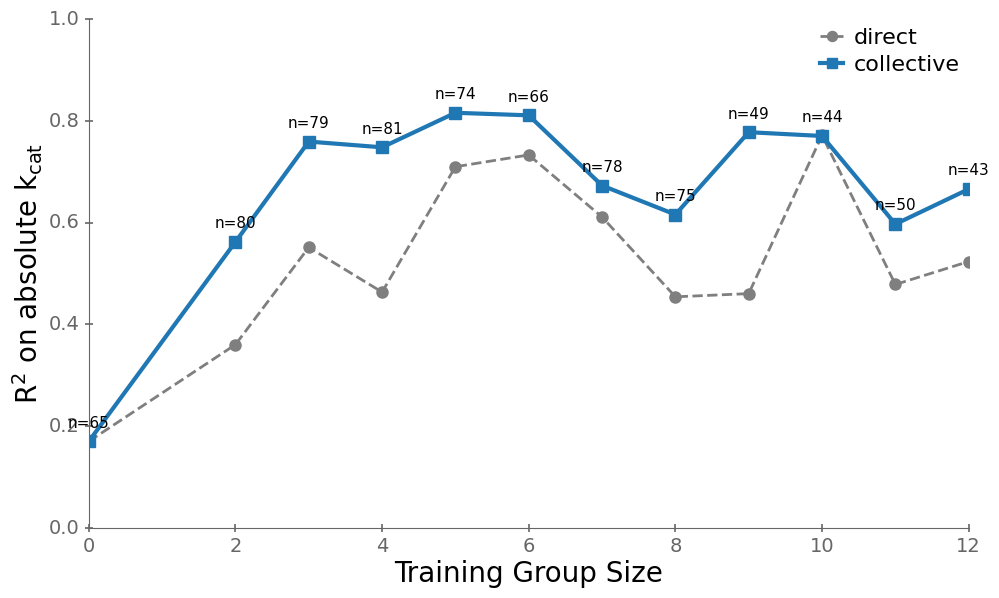

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

# couleurs interverties
line_direct, = ax.plot(
    training_group_sizes, list_r2_pred, label='direct',
    marker='o', linestyle='--', linewidth=2, markersize=8,
    color='tab:grey'
)
line_collective, = ax.plot(
    training_group_sizes, list_r2_collective_pred, label='collective',
    marker='s', linestyle='-', linewidth=3, markersize=8,
    color='tab:blue'
)

eps = 1e-12  # tie-breaker tolerance

for x, y_pred, y_coll, n in zip(training_group_sizes, list_r2_pred,
                                list_r2_collective_pred, list_n):
    # Place n above the higher of the two series
    y = max(y_pred, y_coll)

    ax.annotate(f"n={n}", xy=(x, y), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=11)

ax.set_xlabel('Training Group Size', fontsize=20)
ax.set_ylabel(r'$R^2$ on absolute $k_{cat}$', fontsize=20)

# No horizontal padding
ax.margins(x=0)
xmin, xmax = min(training_group_sizes), max(training_group_sizes)
ax.set_xlim(left=0 if xmin >= 0 else xmin, right=xmax)

ax.set_ylim(0, 1)

# ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=16)

fig.tight_layout()

# Bigger tick labels + thicker/longer ticks on both axes
ax.set_xticks(ax.get_xticks())
ax.set_yticks(ax.get_yticks())
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14, length=6, width=1.2)
ax.tick_params(axis='both', which='minor', length=3, width=1.0)

# A bit of vertical headroom inside the axes
ax.margins(y=0.05)

plt.show()

## 3. Reproduction of Figure 3

In [20]:
import copy
df_test_pairs_wm['pred_delta_coll_delta'] = np.nan

for idx, row in df_test_pairs_wm.iterrows():
    t = row['Type']
    if t == ['wildtype', 'mutant']:
        kcat_wt = row['log10kcat'][0]
        mut_index = row['index'][1]
        df_temp = df_mutant_kcat[df_mutant_kcat['index'] == mut_index]
        kcat_mut = df_temp['collective_pred'].values[0]
        df_test_pairs_wm.at[idx, 'pred_delta_coll_delta'] = kcat_wt - kcat_mut
    elif t == ['mutant', 'wildtype']:
        kcat_wt = row['log10kcat'][1]
        mut_index = row['index'][0]
        df_temp = df_mutant_kcat[df_mutant_kcat['index'] == mut_index]
        kcat_mut = df_temp['collective_pred'].values[0]
        df_test_pairs_wm.at[idx, 'pred_delta_coll_delta'] = kcat_mut - kcat_wt

df_test_pairs_wm_ordered = df_test_pairs_wm.copy()

for idx, row in df_test_pairs_wm_ordered.iterrows():
    if row['Type'] == ['mutant', 'wildtype']:
        for col in df_test_pairs_wm_ordered.columns:
            val = row[col]
            if col in ('Identifier', 'training_group_size'):
                continue
            elif isinstance(val, list):
                df_test_pairs_wm_ordered.at[idx, col] = val[::-1]
            else:
                df_test_pairs_wm_ordered.at[idx, col] = -val

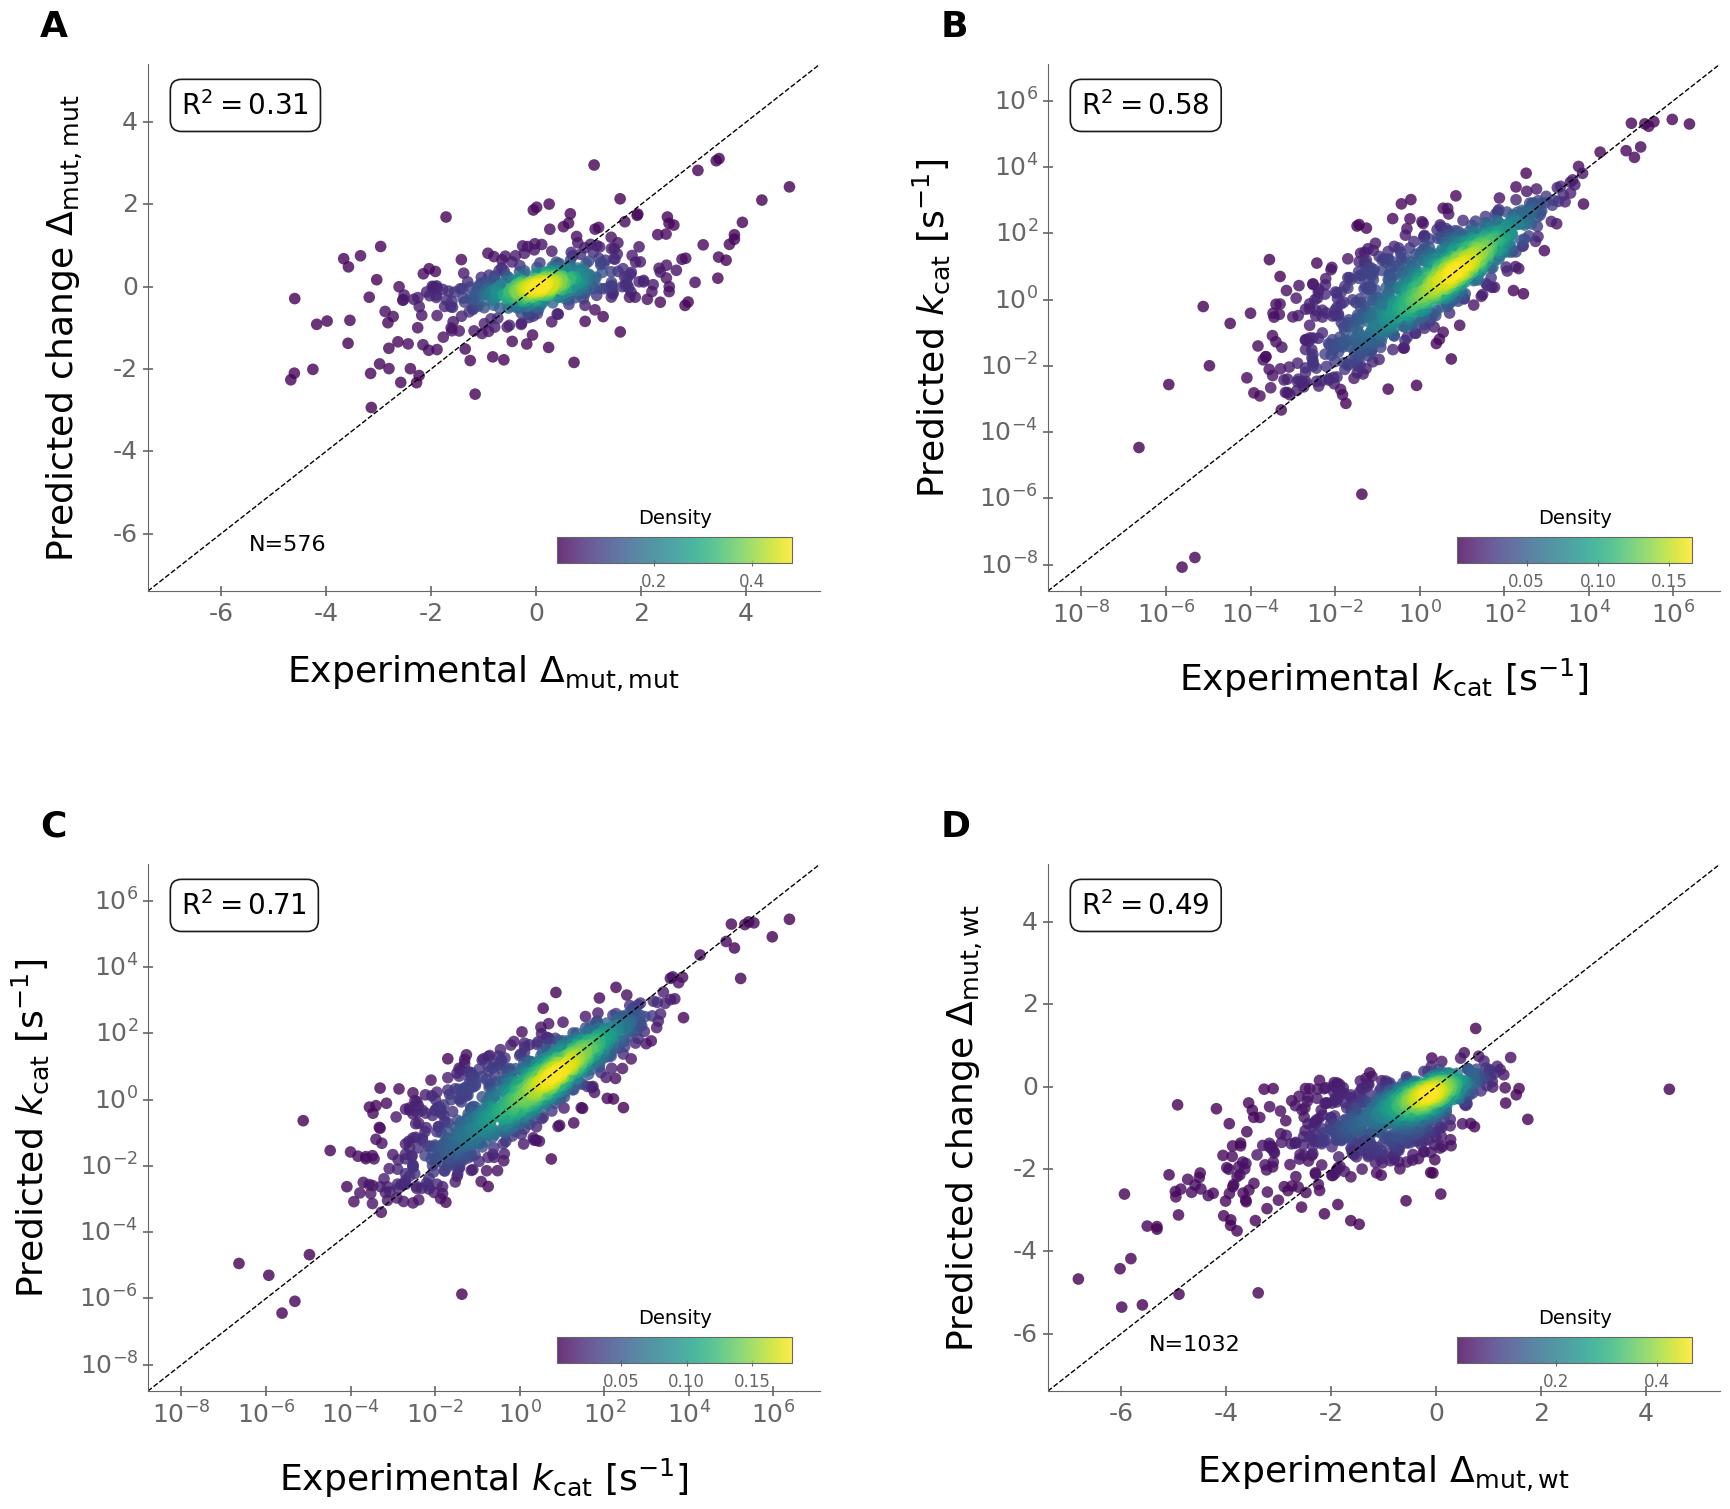

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# --- Combined figure: 2×2 ---
fig, axes = plt.subplots(2, 2, figsize=(18, 16), constrained_layout=True)

_xlab_mm = r"Experimental $\Delta_{\mathrm{mut,mut}}$"
_ylab_mm = r"Predicted change $\Delta_{\mathrm{mut,mut}}$"
_xlab_wm = r"Experimental $\Delta_{\mathrm{mut,wt}}$"
_ylab_wm = r"Predicted change $\Delta_{\mathrm{mut,wt}}$"

# Panel A
p_a = utils_helpers._scatter_panel_v2(
    axes[0, 0],
    df_test_pairs_mm['delta_log_kcat'],
    df_test_pairs_mm['delta_log_kcat_predicted'],
    title="", x_label=_xlab_mm, y_label=_ylab_mm,
)
axes[0, 0].text(0.15, 0.07, f"N={len(df_test_pairs_mm)}",
                transform=axes[0, 0].transAxes, ha='left', va='bottom', fontsize=16)

# Panel B
p_b = utils_helpers._scatter_panel_v2(
    axes[0, 1],
    df_mutant_kcat['log10kcat'],
    df_mutant_kcat['predicted_log10kcat'],
    title="",
    x_label=r"Experimental $\mathit{k}_{\mathrm{cat}}$ [s$^{-1}$]",
    y_label=r"Predicted $\mathit{k}_{\mathrm{cat}}$ [s$^{-1}$]",
)

# Panel C
p_c = utils_helpers._scatter_panel_v2(
    axes[1, 0],
    df_mutant_kcat['log10kcat'],
    df_mutant_kcat['collective_pred'],
    title="",
    x_label=r"Experimental $\mathit{k}_{\mathrm{cat}}$ [s$^{-1}$]",
    y_label=r"Predicted $\mathit{k}_{\mathrm{cat}}$ [s$^{-1}$]",
)

# Panel D
p_d = utils_helpers._scatter_panel_v2(
    axes[1, 1],
    -df_test_pairs_wm_ordered['delta_log_kcat'],
    -df_test_pairs_wm_ordered['pred_delta_coll_delta'],
    title="", x_label=_xlab_wm, y_label=_ylab_wm,
)
axes[1, 1].text(0.15, 0.07, f"N={len(df_test_pairs_wm_ordered)}",
                transform=axes[1, 1].transAxes, ha='left', va='bottom', fontsize=16)

# Shared limits within same-scale panels
lims_delta = utils_helpers._shared_row_limits_v2([p_a, p_d])
if lims_delta is not None:
    lo, hi = lims_delta
    for ax in [axes[0, 0], axes[1, 1]]:
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        for ln in list(ax.get_lines()):
            if ln.get_linestyle() == "--":
                ln.remove()
        ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.0)

lims_abs = utils_helpers._shared_row_limits_v2([p_b, p_c])
if lims_abs is not None:
    lo, hi = lims_abs
    for ax in [axes[0, 1], axes[1, 0]]:
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        for ln in list(ax.get_lines()):
            if ln.get_linestyle() == "--":
                ln.remove()
        ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.0)

# Keep plotting / density / R² in log10 space, but display B and C axes as absolute kcat
for ax in [axes[0, 1], axes[1, 0]]:
    ax.xaxis.set_major_formatter(FuncFormatter(utils_helpers._kcat_formatter_from_log10))
    ax.yaxis.set_major_formatter(FuncFormatter(utils_helpers._kcat_formatter_from_log10))

# Bigger axis labels
for ax in axes.ravel():
    ax.xaxis.label.set_size(26)
    ax.xaxis.labelpad = 20
    ax.yaxis.label.set_size(26)
    ax.yaxis.labelpad = 20

# Panel letters (A, B, C, D)
for i, ax in enumerate(axes.ravel()):
    ax.text(-0.16, 1.04, chr(65 + i), transform=ax.transAxes,
            ha="left", va="bottom", fontsize=26, fontweight="bold", clip_on=False)

# Tick styling
for ax in axes.ravel():
    ax.tick_params(axis="both", which="major", labelsize=18, length=7, width=1.2)
    ax.tick_params(axis="both", which="minor", labelsize=16, length=4, width=1.0)

fig.set_constrained_layout_pads(w_pad=0.45, h_pad=0.55, wspace=0.02, hspace=0.02)

plt.show()

## Reproduction of Figure S5 


Bad key text.latex.preview in file utils/CCB_plot_style_0v4.mplstyle, line 55 ('text.latex.preview  : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file utils/CCB_plot_style_0v4.mplstyle, line 63 ('mathtext.fallback_to_cm : True ## When True, use symbols from the Computer Modern fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


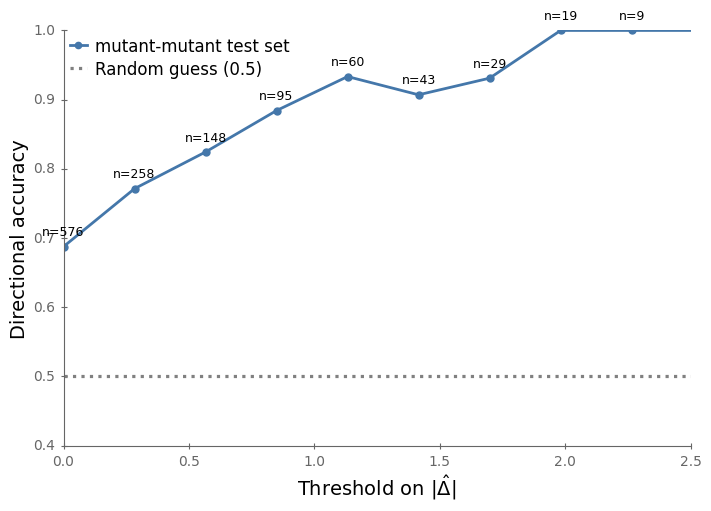

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def accuracy_vs_threshold(y_true, y_pred, n_thresholds=100):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    abs_pred = np.abs(y_pred)
    thresholds = np.linspace(0, abs_pred.max(), n_thresholds)
    accuracies, fractions, counts = [], [], []
    for t in thresholds:
        kept = abs_pred >= t
        n_kept = kept.sum()
        if n_kept == 0:
            accuracies.append(np.nan)
            fractions.append(0.0)
            counts.append(0)
        else:
            correct = np.sign(y_pred[kept]) == np.sign(y_true[kept])
            accuracies.append(correct.sum() / n_kept)
            fractions.append(n_kept / len(y_pred))
            counts.append(int(n_kept))
    return np.array(thresholds), np.array(accuracies), np.array(fractions), np.array(counts)

t_mm, acc_mm, frac_mm, count_mm = accuracy_vs_threshold(df_test_pairs_mm["delta_log_kcat"], df_test_pairs_mm["delta_log_kcat_predicted"], n_thresholds=12)

plt.style.use(Path("utils") / "CCB_plot_style_0v4.mplstyle")
fig, ax_acc = plt.subplots(figsize=(7, 5), constrained_layout=True)

ax_acc.plot(t_mm, acc_mm, linewidth=2, marker='o', label="mutant-mutant test set")
for x, y, n in zip(t_mm, acc_mm, count_mm):
    if np.isfinite(y):
        ax_acc.annotate(f"n={n}", xy=(x, y), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)
ax_acc.axhline(0.5, color="gray", linestyle=":", linewidth=2.3, label="Random guess (0.5)")
ax_acc.set_xlabel(r"Threshold on $|\hat{\Delta}|$", fontsize=14)
ax_acc.set_ylabel("Directional accuracy", fontsize=14)
ax_acc.set_ylim(0.4, 1.0)
ax_acc.set_xlim(0, 2.5)
ax_acc.legend(fontsize=12, frameon=False)

plt.show()